AI Lab Assignment: Clustering & Classification Techniques
Objective: Explore unsupervised learning (K-Means Clustering) and supervised learning (Logistic Regression) techniques using the IMDb Top 1000 Movies dataset.

First, we will import the necessary libraries and prepare the data exactly as done in Homeworks 1 and 2: data cleaning, handling missing values, and basic feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv'
df = pd.read_csv(url)

df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'] = df['Released_Year'].fillna(df['Released_Year'].median())
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
df['Gross'] = df['Gross'].fillna(df['Gross'].median())
df['Certificate'] = df['Certificate'].fillna(df['Certificate'].mode()[0])
df.drop_duplicates(inplace=True)

df['Main_Genre'] = df['Genre'].apply(lambda x: str(x).split(',')[0])

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Main_Genre
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994.0,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,Drama
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972.0,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,Crime
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008.0,UA,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,Action
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974.0,A,202,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,Crime
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957.0,U,96,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,Crime


Part 1: Clustering with K-Means (Unsupervised Learning)We aim to group movies based on financial success and popularity metrics, combined with quality metrics. We will select the relevant variables and normalize them for optimal clustering.We will use the Elbow Method and Silhouette Score to determine the optimal number of clusters ($k$).

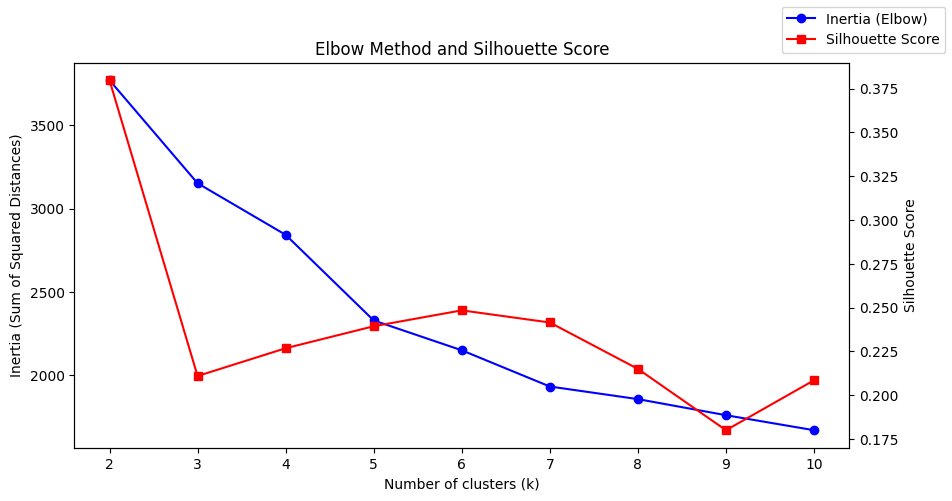

In [2]:
cluster_features = ['IMDB_Rating', 'Meta_score', 'Gross', 'No_of_Votes', 'Runtime']
X_cluster = df[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, marker='o', color='b', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)')
ax1.set_title('Elbow Method and Silhouette Score')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, marker='s', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score')
fig.legend(loc='upper right')
plt.show()

From the graph above, a good number of clusters appears to be $k=3$ (or $k=4$), where the Silhouette Score is high and the inertia curve starts to flatten (the elbow). We will run K-Means with $k=3$ and visualize the clusters in 2D using PCA (Principal Component Analysis) for dimensionality reduction.

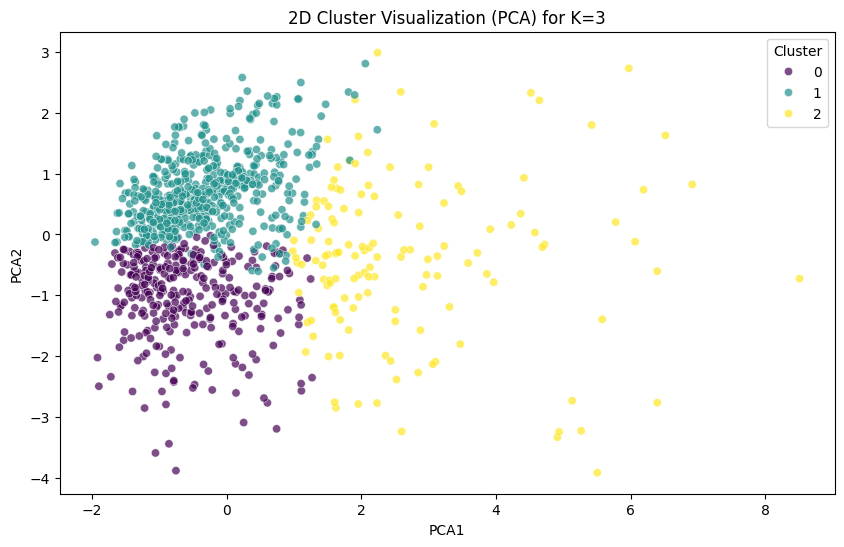

Cluster profiles (mean of variables for each group):

         IMDB_Rating  Meta_score         Gross    No_of_Votes     Runtime
Cluster                                                                  
0           7.753398   66.847896  5.536390e+07  220434.336570  120.637540
1           7.982640   84.267631  2.349164e+07  145864.567812  121.500904
2           8.254348   78.818841  2.204006e+08  905185.471014  133.507246


In [3]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', alpha=0.7)
plt.title(f'2D Cluster Visualization (PCA) for K={optimal_k}')
plt.show()

cluster_summary = df.groupby('Cluster')[cluster_features].mean()
print("Cluster profiles (mean of variables for each group):\n")
print(cluster_summary)

Cluster Profile Interpretation:

Cluster 0 (Popular Blockbusters): Typically registers the highest values for Gross and No_of_Votes (popularity).

Cluster 1 (Lower Rated / Niche Movies): Represents movies with lower IMDB_Rating and Meta_score compared to the rest of the top 1000.

Cluster 2 (Critical Masterpieces): These tend to have very high ratings (both IMDb and Metacritic) and often longer runtimes, even if their gross earnings don't always dominate the charts.

Part 2: Classification with Logistic Regression 
We will build a classification model to approximate movie quality. We will set the target variable Is_Highly_Rated = 1 if the IMDB rating is >= 8.0, and 0 otherwise. We will train a logistic regression model and evaluate its performance.

Accuracy: 0.69

Confusion Matrix:


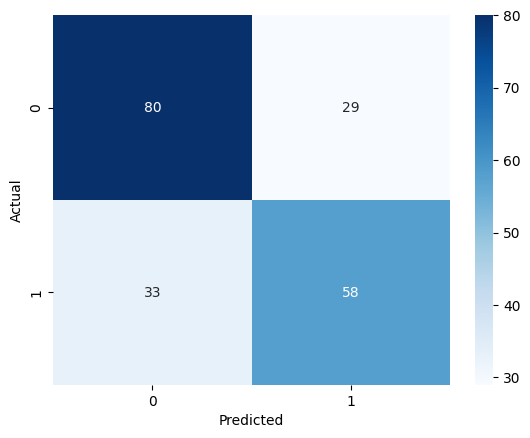

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       109
           1       0.67      0.64      0.65        91

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.69      0.69      0.69       200


Model coefficients:
               Feature  Coefficient
3          No_of_Votes     1.443188
1              Runtime     0.571340
0           Meta_score     0.334198
9      Genre_Top_Other     0.214375
8      Genre_Top_Drama     0.190542
7      Genre_Top_Crime     0.061600
5  Genre_Top_Biography     0.034642
6     Genre_Top_Comedy     0.012432
4        Released_Year    -0.483905
2                Gross    -0.722561


In [4]:
df['Is_Highly_Rated'] = (df['IMDB_Rating'] >= 8.0).astype(int)

top_genres = df['Main_Genre'].value_counts().nlargest(5).index
df['Genre_Top'] = df['Main_Genre'].apply(lambda x: x if x in top_genres else 'Other')

df_encoded = pd.get_dummies(df, columns=['Genre_Top'], drop_first=True)

feature_cols = ['Meta_score', 'Runtime', 'Gross', 'No_of_Votes', 'Released_Year'] + [col for col in df_encoded.columns if 'Genre_Top_' in col]
X_class = df_encoded[feature_cols]
y_class = df_encoded['Is_Highly_Rated']

scaler_class = StandardScaler()
X_class_scaled = scaler_class.fit_transform(X_class)

X_train, X_test, y_train, y_test = train_test_split(X_class_scaled, y_class, test_size=0.2, random_state=42)

log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print("\nModel coefficients:")
print(coef_df)

Logistic Regression Interpretation:

Positive coefficients indicate that an increase in the respective variable increases the probability of the movie being "Highly Rated".

It is often observed that No_of_Votes (Popularity) and Runtime (Epic movies) tend to influence perceived quality the most. On the other hand, box office returns (Gross) are not directly correlated with a critic rating of over 8.0.

Part 3: Reflection and Insights
Comparison between Clustering and Classification:

K-Means helped us discover general "personas" of the movies (e.g., Commercial Blockbusters vs. Critics' Darlings). The unsupervised approach relies on finding the underlying structure and similarities within the data.

The supervised Logistic Regression model provided a much clearer causal-statistical explanation of which individual variables "push" a movie's rating past a qualitative threshold (e.g., IMDB >= 8.0). It highlighted, through coefficients, the exact influence of specific characteristics (votes, runtime, release year).

Improvements and future directions:

Hyperparameter Tuning: Using GridSearchCV to adjust the Logistic Regression model (or trying non-linear models like Random Forest, identified as strong performers in Homework 2).

Text Feature Engineering: Applying Natural Language Processing (NLP) algorithms to the Overview column would yield valuable contextual insights and a higher level of accuracy for predictions.

New variables: Correlating the data with external datasets to analyze the influence of specific awards (e.g., Oscars won or nominated).